# 📘 Week 5 - Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

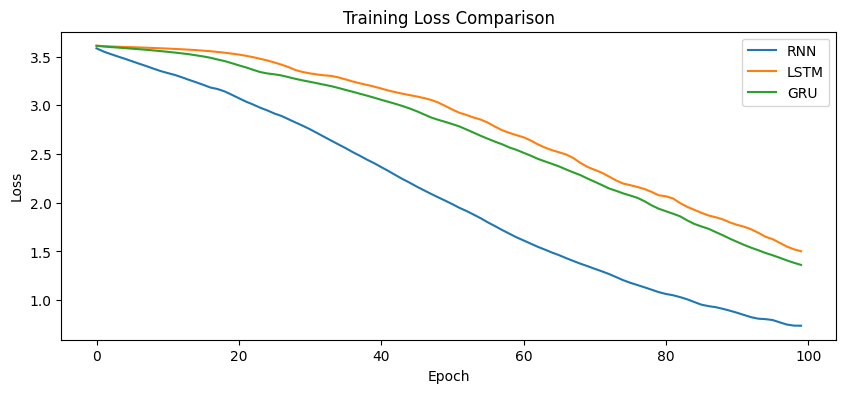

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is can generate meaningful sentences
LSTM: deep learning models can meaningful meaningful meaningful
GRU : deep learning models can generate meaningful next


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✍️ Beginner Task Solutions


### 🔷 Task 1 – Replace the corpus with your own paragraph

In [10]:
custom_corpus = """
Interstellar is a science fiction film about hope, exploration, and survival.
The story follows Cooper, a former pilot who joins a mission to save humanity.
Earth is slowly becoming uninhabitable because crops are failing across the planet.
A mysterious wormhole appears near Saturn and offers a path to distant galaxies.
Cooper and his team travel through the wormhole to search for habitable planets.
Every planet presents a different challenge and tests the courage of the astronauts.
One planet has enormous waves caused by the intense gravitational pull of a nearby black hole.
Another planet teaches the crew that time moves differently under extreme gravity.
Every hour spent on that planet costs many years back on Earth.
Murph refuses to give up and continues searching for a scientific solution to save humanity.
Cooper believes that love, hope, and determination can guide people through impossible situations.
The mission becomes a journey about sacrifice, family, and the future of civilization.
The black hole reveals mysteries that challenge the limits of human understanding.
Gravity becomes the key to connecting different moments across space and time.
In the end, human curiosity and perseverance prove stronger than fear and uncertainty.
Interstellar reminds us that exploration begins with asking difficult questions and never giving up."""

tokenizer_task = Tokenizer()
tokenizer_task.fit_on_texts([custom_corpus])

total_words_task = len(tokenizer_task.word_index) + 1

input_sequences = []
for line in custom_corpus.split('\n'):
    token_list = tokenizer_task.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

max_len_task = max(len(x) for x in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len_task,
    padding='pre'
)

X_task = input_sequences[:, :-1]
y_task = input_sequences[:, -1]

print("Vocabulary Size:", total_words_task)

Vocabulary Size: 137


### 🔷Task 2, Task 3 & Task 4

The following modifications were applied to all three sequence models (RNN, LSTM, and GRU):

- Increased the embedding dimension from **32** to **64**.
- Increased the hidden units from **64** to **128**.
- Increased the training epochs from **100** to **200**.

These changes allow the models to learn richer word representations, capture more complex sequential patterns, and train for additional iterations to improve learning.

**Model 1: Vanilla RNN**

In [11]:
print("Training Modified RNN Model...")

task_rnn = Sequential([
    Embedding(total_words_task, 64, input_length=max_len_task-1),
    SimpleRNN(128),
    Dense(total_words_task, activation='softmax')
])

task_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

task_rnn_history = task_rnn.fit(
    X_task,
    y_task,
    epochs=200,
    verbose=0
)

print("✅ Modified RNN Completed")

Training Modified RNN Model...
✅ Modified RNN Completed


**Model 2: LSTM**

In [12]:
print("\nTraining Modified LSTM Model...")

task_lstm = Sequential([
    Embedding(total_words_task, 64, input_length=max_len_task-1),
    LSTM(128),
    Dense(total_words_task, activation='softmax')
])

task_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

task_lstm_history = task_lstm.fit(
    X_task,
    y_task,
    epochs=200,
    verbose=0
)

print("✅ Modified LSTM Completed")


Training Modified LSTM Model...
✅ Modified LSTM Completed


**Model 3: GRU**

In [13]:
print("\nTraining Modified GRU Model...")

task_gru = Sequential([
    Embedding(total_words_task, 64, input_length=max_len_task-1),
    GRU(128),
    Dense(total_words_task, activation='softmax')
])

task_gru.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

task_gru_history = task_gru.fit(
    X_task,
    y_task,
    epochs=200,
    verbose=0
)

print("✅ Modified GRU Completed")


Training Modified GRU Model...
✅ Modified GRU Completed


### 🔷 Task 5: Generate 10 Words

The trained RNN, LSTM, and GRU models were used to generate **10 words** from the given seed text using the custom Interstellar corpus.

In [14]:
def generate_task_text(model, seed_text, next_words=10):
    for _ in range(next_words):

        token_list = tokenizer_task.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len_task-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer_task.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text


print("Modified RNN :")
print(generate_task_text(task_rnn, "interstellar", 10))

print("\n" + "="*80 + "\n")

print("Modified LSTM :")
print(generate_task_text(task_lstm, "interstellar", 10))

print("\n" + "="*80 + "\n")

print("Modified GRU :")
print(generate_task_text(task_gru, "interstellar", 10))

Modified RNN :
interstellar reminds us that exploration begins with asking difficult questions and


Modified LSTM :
interstellar is a science fiction film about hope exploration and survival


Modified GRU :
interstellar is a science fiction film about hope exploration and survival


# 🔎 Comparison Of Models
**Training Loss Comparison**

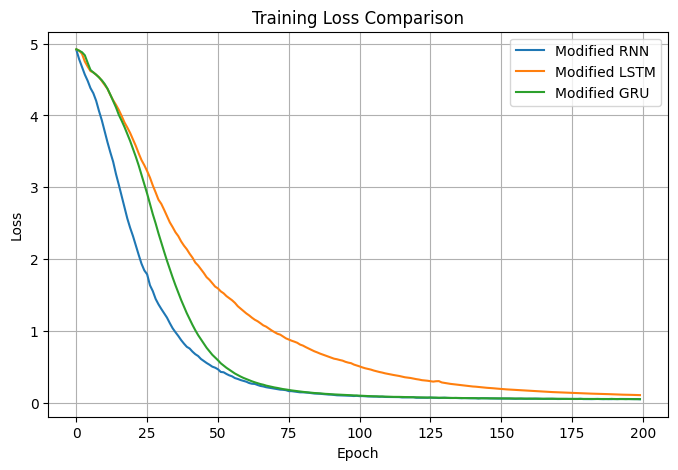

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(task_rnn_history.history['loss'], label='Modified RNN')
plt.plot(task_lstm_history.history['loss'], label='Modified LSTM')
plt.plot(task_gru_history.history['loss'], label='Modified GRU')

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**